# 1. Data exploration: from prices to a model-ready return matrix

**What you will do in this notebook**

1. Look at the project settings (which assets, which dates).
2. Download prices (or read them from the local cache) and clean them.
3. Turn prices into **log returns**, the quantity the copula models are fitted to.
4. See why a plain correlation is not enough: returns have fat tails.

**Before you start:** nothing. The first run downloads prices from Yahoo Finance (a few seconds)
and stores them in `data/cache/`; later runs read that file, so they work offline.

**How to run it:** `jupyter lab` from the project folder, open this file, and choose
*Run > Run All Cells* (or press Shift+Enter cell by cell). Each code cell prints what it did.

In [1]:
import os, warnings
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":      # notebooks run from the notebooks/ folder; the project root is one level up
    ROOT = ROOT.parent
os.chdir(ROOT)                    # all paths below are relative to the project folder
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 140); pd.set_option("display.max_columns", 30)
print("working folder:", Path.cwd().name)

working folder: Quant_copula


## 1.1 The settings

All settings live in one small text file, `configs/default.yaml` (YAML is just indented `key: value` lines).
`load_config` reads it into a Python object so that no setting is hard-coded in the code.

In [2]:
from vine_risk.config import load_config

cfg = load_config("configs/default.yaml")
print("assets :", cfg.assets)
print("data   :", cfg.data)
print("rolling:", cfg.rolling)

assets : ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM', 'JNJ', 'SPY', 'TLT']
data   : DataConfig(frequency='daily', start='2005-01-01', end=None, cache_dir='data/cache', max_missing_frac=0.05, max_ffill_days=3)
rolling: RollingConfig(window=250, refit_frequency=1, truncation_level=3, selection_criterion='bic', n_jobs=4, tail_simulations=16384, tail_level=0.05)


**Using your own tickers.** Either edit the `assets:` list in `configs/default.yaml`, or create a modified copy in
Python as below (the last line shows how you would then load the data; it is left commented out so that this
notebook keeps using the default assets). Any ticker that Yahoo Finance knows works, but keep the number of
assets small (the PDF suggests 5 to 10); the cost of a vine fit grows quickly with the number of assets.

In [3]:
from dataclasses import replace

my_cfg = replace(cfg, assets=["SPY", "TLT", "GLD", "XLE"])
print(my_cfg.assets)
# prices, returns = load_prices_and_returns(my_cfg)   # <- would download and clean these four instead

['SPY', 'TLT', 'GLD', 'XLE']


## 1.2 Prices

`download_prices` fetches **adjusted** daily close prices (adjusted for splits and dividends, so that corporate
actions do not look like market moves). The result is a table with one row per day and one column per ticker.

In [4]:
from vine_risk.data import download_prices, clean_prices

raw = download_prices(cfg.assets, cfg.data.start, cfg.data.end, cfg.data.cache_dir)
print("raw prices:", raw.shape, "(days x assets)")
raw.tail()

raw prices: (5472, 8) (days x assets)


Ticker,AAPL,MSFT,NVDA,JPM,XOM,JNJ,SPY,TLT
Date,,,,,,,,
2026-09-28,338.399994,509.220001,228.860001,336.589996,162.520004,271.950012,765.609985,78.304634
2026-09-29,329.399994,508.959991,227.210007,334.980011,161.350006,267.570007,764.200012,77.916199
2026-09-30,333.019989,512.900024,228.380005,330.829987,162.750000,264.739990,762.630005,77.467995
2026-10-01,330.320007,512.799988,230.860001,333.179993,163.820007,258.660004,763.989990,77.709999
2026-10-02,333.690002,517.530029,233.949997,332.380005,164.009995,256.029999,769.640015,77.480003


Assets do not always exist from the same date (think of a recent stock market listing). A copula needs all assets observed
on the same days, so the cleaning step (`clean_prices`) keeps only the days on which every asset has a price, after repairing
short gaps. Which asset starts last? For the default universe all eight assets have prices from the first day, so nothing is
dropped; if you add a younger asset, the history will start on that asset's first day.

In [5]:
first_day = raw.apply(lambda s: s.first_valid_index()).sort_values()
print(first_day.to_string())

clean = clean_prices(raw, cfg.data.max_missing_frac, cfg.data.max_ffill_days)
print(f"\nafter cleaning: {clean.shape[0]} days from {clean.index[0].date()} to {clean.index[-1].date()} "
      f"({raw.shape[0] - clean.shape[0]} days dropped)")

Ticker
AAPL   2005-01-03
MSFT   2005-01-03
NVDA   2005-01-03
JPM    2005-01-03
XOM    2005-01-03
JNJ    2005-01-03
SPY    2005-01-03
TLT    2005-01-03

after cleaning: 5472 days from 2005-01-03 to 2026-10-02 (0 days dropped)


### What the cleaning does with missing data

A small experiment on a copy of the data. We punch two kinds of holes in it: a short gap of 2 days in the first
asset, and a long gap of 10 days in the second. The rules (set in the config) are: forward-fill gaps of up to
`max_ffill_days = 3` days, then drop any day that is still incomplete.

In [6]:
toy = clean.iloc[:30, :3].copy()
toy.iloc[5:7, 0] = np.nan       # 2-day gap in the first asset: will be filled
toy.iloc[10:20, 1] = np.nan     # 10-day gap in the second asset: only 3 days can be filled
repaired = clean_prices(toy, max_missing_frac=0.5, max_ffill_days=3)
print("rows before:", len(toy), "| rows after:", len(repaired))
print("days removed:", sorted(set(toy.index) - set(repaired.index))[:1], "... (the 7 days of the long gap that could not be filled)")
repaired.iloc[3:9]

rows before: 30 | rows after: 23
days removed: [Timestamp('2005-01-21 00:00:00')] ... (the 7 days of the long gap that could not be filled)


Ticker,AAPL,MSFT,NVDA
Date,,,
2005-01-06,0.965333,18.311129,0.171201
2005-01-07,1.035621,18.256365,0.167922
2005-01-10,1.035621,18.345356,0.168304
2005-01-11,1.035621,18.297430,0.163120
2005-01-12,0.978943,18.331671,0.161748
2005-01-13,1.043846,17.982552,0.163426


Two other rules you can see in `clean_prices`: an asset with more than `max_missing_frac` (5 %) missing prices is
dropped entirely (with a warning in the log), and non-positive prices are treated as missing.

## 1.3 Log returns

Copulas are fitted to **returns**, never to prices. The log return of asset *i* on day *t* is

$$r_{i,t} = \log\frac{P_{i,t}}{P_{i,t-1}}$$

where $P$ is the adjusted price. Log returns add up over time, which is convenient. Check the formula by hand
for one asset and one day:

In [7]:
from vine_risk.returns import log_returns, build_return_matrix

returns = log_returns(clean)
p = clean["SPY"]
print("by hand       :", np.log(p.iloc[1] / p.iloc[0]))
print("log_returns() :", returns["SPY"].iloc[0])

# build_return_matrix does the whole chain in one call: clean -> adjust -> log returns -> drop incomplete days
R = build_return_matrix(raw, cfg.data.max_missing_frac, cfg.data.max_ffill_days)
print("\nreturn matrix R:", R.shape, "= T days x d assets | identical to the step-by-step version:",
      np.allclose(R.to_numpy(), returns.to_numpy()))

by hand       : -0.012294870658504523
log_returns() : -0.012294870658504523

return matrix R: (5471, 8) = T days x d assets | identical to the step-by-step version: True


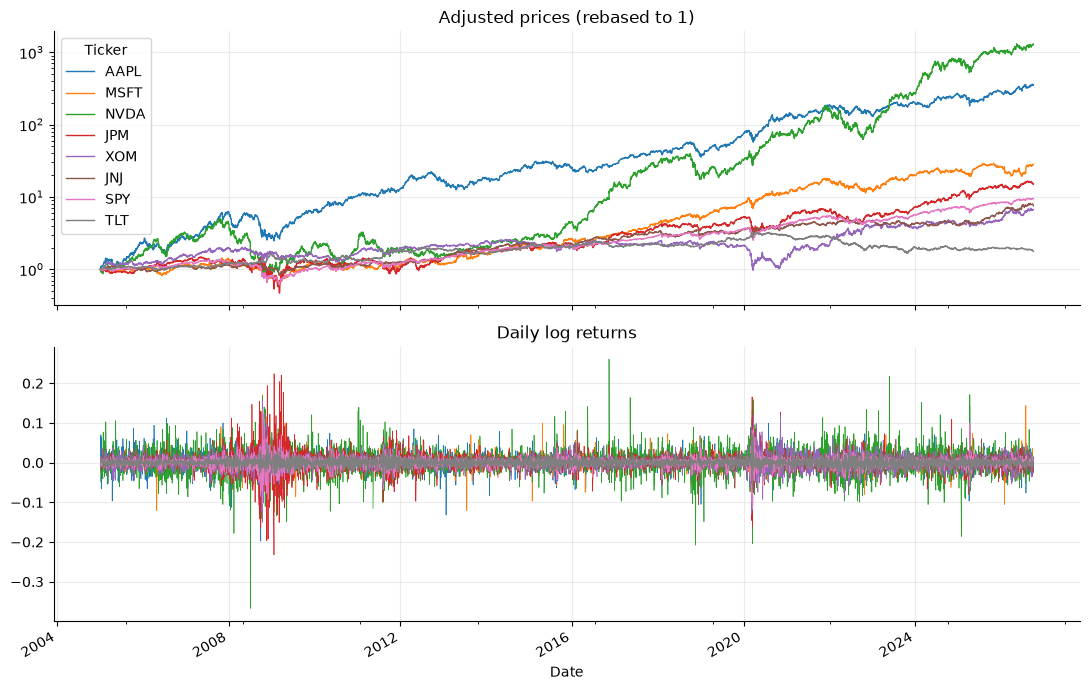

In [8]:
from vine_risk.visualization import plot_prices_returns

plot_prices_returns(clean, R)
plt.show()

This matrix `R` (T rows by d columns) is the **model-ready return matrix**: everything that follows starts from it.

## 1.4 Why a copula? What the returns look like

Two facts motivate the whole project. First, returns are **not normally distributed**: extreme days are far more
common than a bell curve predicts (measured by *excess kurtosis*, which is 0 for a normal distribution).

In [9]:
from scipy import stats

summary = pd.DataFrame({
    "annual vol": R.std() * np.sqrt(252),
    "skewness": R.apply(stats.skew),
    "excess kurtosis": R.apply(stats.kurtosis),
    "worst day": R.min(),
    "best day": R.max(),
})
summary.round(3)

,annual vol,skewness,excess kurtosis,worst day,best day
Ticker,,,,,
AAPL,0.320,-0.217,6.102,-0.197,0.143
MSFT,0.273,0.050,9.771,-0.159,0.171
NVDA,0.483,-0.273,8.775,-0.367,0.261
JPM,0.353,0.251,18.318,-0.232,0.224
XOM,0.265,-0.111,9.203,-0.150,0.159
JNJ,0.173,-0.028,10.529,-0.106,0.115
SPY,0.189,-0.304,14.757,-0.116,0.136
TLT,0.145,0.007,3.456,-0.069,0.073


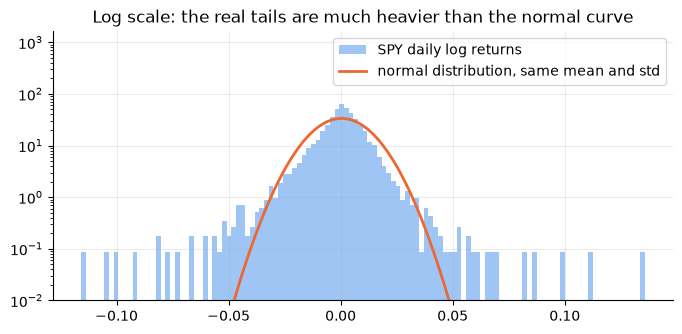

In [10]:
spy = R["SPY"]
x = np.linspace(spy.min(), spy.max(), 400)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(spy, bins=120, density=True, color="#9ec5f4", label="SPY daily log returns")
ax.plot(x, stats.norm.pdf(x, spy.mean(), spy.std()), color="#eb6834", lw=2, label="normal distribution, same mean and std")
ax.set_yscale("log"); ax.set_ylim(1e-2, None); ax.legend()
ax.set_title("Log scale: the real tails are much heavier than the normal curve")
plt.show()

Second, the **dependence between assets** is not captured by one number either. The usual correlation matrix is a start:

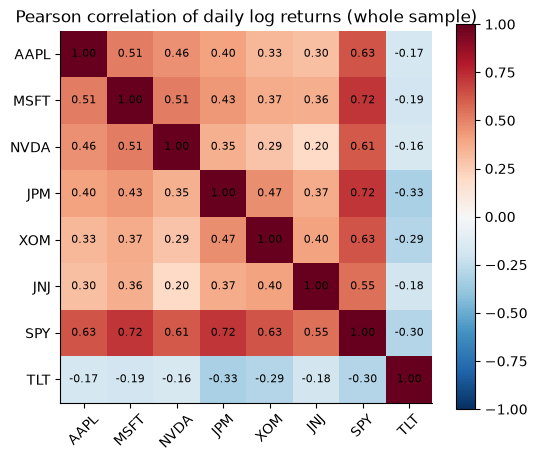

In [11]:
corr = R.corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns); ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im); ax.set_title("Pearson correlation of daily log returns (whole sample)")
plt.show()

A single correlation says nothing about **how assets behave together in a crash**, and it changes over time. A *copula*
describes the dependence separately from each asset's own distribution, and a *vine copula* can do so with a flexible
mix of building blocks. That is what the next notebooks do.

**Things to try:** change `cfg.data.start` (for example `replace(cfg.data, start="2015-01-01")` inside a new `Config`),
change the tickers, or find the days on which all assets fell together: `R[(R < 0).all(axis=1)]`.

Next: `02_static_vine.ipynb`, fitting one vine copula to a window of this data.